In [1]:
import os
os.chdir('/Users/jeffreybloodworth/Desktop/git-repos/scRNAseq-ExplainableML')
os.getcwd()

'/Users/jeffreybloodworth/Desktop/git-repos/scRNAseq-ExplainableML'

In [9]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
X = pd.read_csv(
    "data/processed/ml_matrix_top2000.csv.gz",
    index_col=0
)

meta = pd.read_csv(
    "data/processed/pdc_metadata.csv"
)

print(X.shape)
print(meta.shape)

(4846, 2000)
(14430, 58)


In [12]:
meta["is_malignant"].value_counts()

is_malignant
Malignant       13732
Premalignant      495
Healthy           203
Name: count, dtype: int64

In [10]:
y = pdc_meta["is_malignant"].map({
    "Premalignant": 0,
    "Malignant": 1
})

y.value_counts()

NameError: name 'pdc_meta' is not defined

In [13]:
meta.columns[:5]


Index(['cell', 'orig.ident', 'orig.ident2', 'nCount_RNA', 'nFeature_RNA'], dtype='str')

In [14]:
meta.shape

(14430, 58)

In [15]:
meta.columns[0]

'cell'

In [16]:
barcode_col = meta.columns[0]

meta_rf = meta[
    meta[barcode_col].isin(X.index)
].copy()

print(meta_rf.shape)

(4846, 58)


In [18]:
meta_rf = (
    meta_rf
    .set_index(barcode_col)
    .loc[X.index]
    .reset_index()
)


In [20]:
print(meta_rf.columns.tolist())
print(meta_rf.head())

['index', 'orig.ident', 'orig.ident2', 'nCount_RNA', 'nFeature_RNA', 'replicate', 'tech', 'CellType', 'project.umap.x', 'project.umap.y', 'MALAT1.chr11:65270399:G/A', 'NFIC.chr19:3462800:G/A', 'NOTCH1.chr9:139389423:C/T', 'TET2.Q1537*', 'bm_involvement', 'is_malignant', 'sample', 'TET2.N281fs*', 'TET2.V1395fs*', 'ZRSR2.Y175*', 'ASXL1.L697fs*', 'FAM98C.chr19:38899400:G/A', 'SETX.chr9:135136947:G/A', 'SMARCC1.chr3:47627735:G/A', 'TET2.Q960*', 'ASXL1.R693*', 'TET2.Q876*', 'TET2.S794*', 'ZRSR2.R126*', 'CUX1.L911fs*', 'TET2.E1437fs*', 'TET2.Q1547*', 'ETV6.R369W', 'EZH2.P132L', 'IDH2.R140Q', 'UMAP_1', 'UMAP_2', 'S.Score', 'G2M.Score', 'Phase', 'ASXL1.V807fs*', 'TET2.R1516*', 'U2AF1.S34F', 'ACAP2.L97M', 'ASXL1.G642fs', 'CWF19L2.K221R', 'DOLPP1.R227S', 'HNRNPUL1.F559F', 'MAP4K5.P667S', 'RAB9A.3pUTR', 'TET2.H1380Y', 'TET2.Q1034*', 'TET2.R1216*', 'TET2.S792*', 'MTAP.rearr', 'PRKDC.chr8:48713410:C/T', 'RPS24.chr10:79795273:T/C', 'SMARCD1.chr12:50490729:C/T']
                  index orig.ident ori

In [21]:
all(
    meta_rf["index"].values
    ==
    X.index.values
)

True

In [22]:
print(X.shape)
print(meta_rf.shape)

(4846, 2000)
(4846, 58)


In [23]:
meta_rf["is_malignant"].value_counts()


is_malignant
Malignant       4405
Premalignant     441
Name: count, dtype: int64

In [24]:
y = meta_rf["is_malignant"].map({
    "Premalignant": 0,
    "Malignant": 1
})

print(len(y))
print(X.shape)

4846
(4846, 2000)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

In [29]:
rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [30]:
pred = rf.predict(X_test)

In [31]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        88
           1       1.00      1.00      1.00       882

    accuracy                           1.00       970
   macro avg       0.99      1.00      1.00       970
weighted avg       1.00      1.00      1.00       970



In [32]:
importance = pd.DataFrame({
    "gene": X.columns,
    "importance": rf.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(20)

,gene,importance
1555,ALKBH7,0.034510
159,HES6,0.029758
238,ALOX5AP,0.027202
1198,SHTN1,0.026159
1546,SIGLEC6,0.023957
190,PDLIM1,0.021746
1697,SIRPG,0.019552
934,RAMP1,0.018288
1777,SLC25A11,0.018233
1962,SINHCAF,0.018077


In [33]:
importance.to_csv(
    "results/rf_feature_importance.csv",
    index=False
)

[[ 88   0]
 [  1 881]]


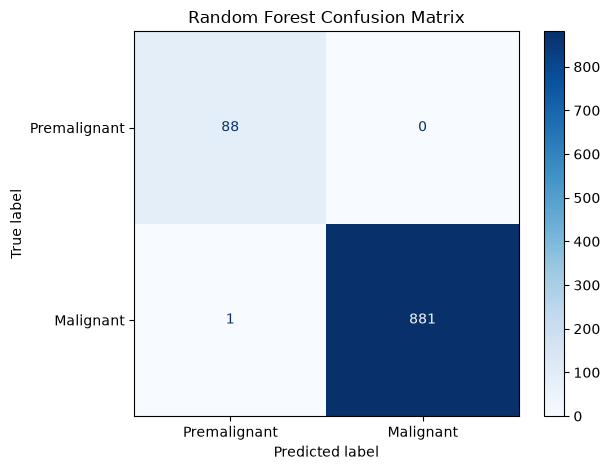

In [34]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    pred
)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Premalignant",
        "Malignant"
    ]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    "figures/rf_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
importance = pd.DataFrame({
    "gene": X.columns,
    "importance": rf.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

In [36]:
top20 = importance.head(20)

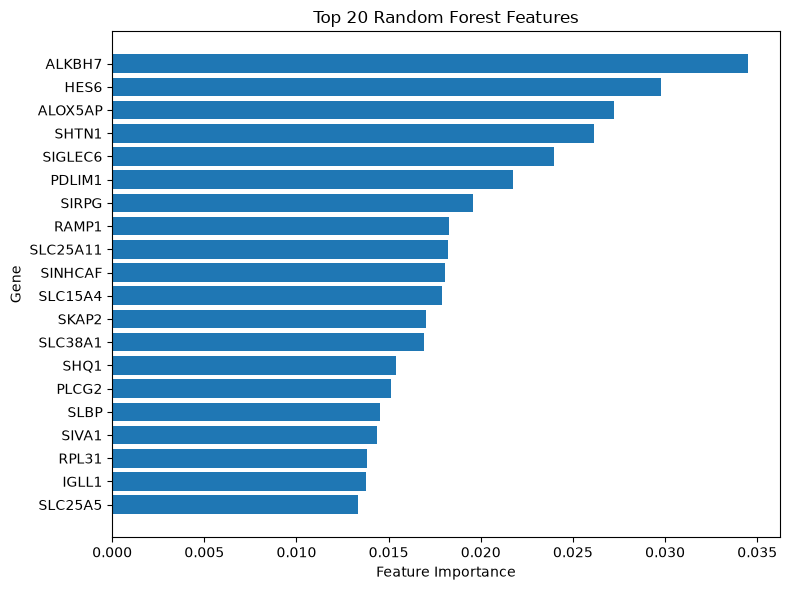

In [37]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(8, 6)
)

plt.barh(
    top20["gene"],
    top20["importance"]
)

plt.gca().invert_yaxis()

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Gene"
)

plt.title(
    "Top 20 Random Forest Features"
)

plt.tight_layout()

plt.savefig(
    "figures/rf_top20_genes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
importance.to_csv(
    "results/rf_feature_importance.csv",
    index=False
)

In [39]:
importance.head(20)

,gene,importance
1555,ALKBH7,0.034510
159,HES6,0.029758
238,ALOX5AP,0.027202
1198,SHTN1,0.026159
1546,SIGLEC6,0.023957
190,PDLIM1,0.021746
1697,SIRPG,0.019552
934,RAMP1,0.018288
1777,SLC25A11,0.018233
1962,SINHCAF,0.018077
